#  Portfolio Risk Assessment - Value at Risk (VaR) System

**Author:** Saina Parween 
**Date:** February 2026  
**Project:** Quantitative Finance - Risk Management  

---

##  Project Overview

This notebook implements **6 comprehensive risk assessment methodologies** to analyze portfolio downside risk:

1.  **Historical VaR** - Empirical percentile from past data
2.  **Variance-Covariance VaR** - Parametric assuming normal distribution  
3.  **Conditional VaR (CVaR)** - Expected shortfall / tail risk
4.  **Monte Carlo VaR** - Simulation-based (1000 scenarios, 10-day horizon)
5.  **Stress Testing** - Scenario analysis under extreme conditions
6.  **Marginal VaR** - Risk decomposition showing each asset's contribution

**Portfolio Analyzed:** $1M tech portfolio (AAPL 40%, MSFT 30%, GOOGL 30%)  
**Data Period:** January 2020 - January 2024  
**Confidence Level:** 95%

---

##  Section 1: Setup & Library Imports

Import all required libraries and configure settings.

In [1]:
# ═══════════════════════════════════════════════
# IMPORTS
# ═══════════════════════════════════════════════

# Standard libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats
import warnings

# External library for data
import yfinance as yf

# ═══════════════════════════════════════════════
# CONFIGURATION
# ═══════════════════════════════════════════════

# Suppress warnings
warnings.filterwarnings('ignore')

# Set plotting style
plt.style.use('seaborn-v0_8-darkgrid')
%matplotlib inline

# Set pandas display options
pd.set_option('display.max_columns', None)
pd.set_option('display.precision', 4)
pd.set_option('display.float_format', lambda x: f'{x:.4f}')

# ═══════════════════════════════════════════════
# VERIFY IMPORTS
# ═══════════════════════════════════════════════

print("All libraries imported successfully!")
print(f"   NumPy version:  {np.__version__}")
print(f"   Pandas version: {pd.__version__}")


All libraries imported successfully!
   NumPy version:  2.3.5
   Pandas version: 2.3.3


---

##  Section 2: Data Loading Class

The `DataLoader` class handles:
- Fetching historical stock prices from Yahoo Finance
- Converting prices to **log returns**
- Data validation and cleaning

###  Why Log Returns?

Log returns are preferred in quantitative finance because:

$$r_t = \ln\left(\frac{P_t}{P_{t-1}}\right)$$

**Advantages:**
-  **Time-additive:** Can sum across periods
-  **Symmetric:** ±5% is truly symmetric  
-  **Normally distributed:** Better for statistical modeling
-  **Handles compounding:** Natural for multi-period returns

---

In [2]:
# ═══════════════════════════════════════════════
# DATA LOADER CLASS
# ═══════════════════════════════════════════════

class DataLoader:
    """
    Fetch and preprocess financial market data
    
    This class handles data acquisition from Yahoo Finance
    and converts prices to log returns.
    
    Attributes:
        tickers (list): Stock symbols to fetch (e.g., ['AAPL', 'MSFT'])
        start_date (str): Start date in 'YYYY-MM-DD' format
        end_date (str): End date in 'YYYY-MM-DD' format
        prices (DataFrame): Adjusted close prices
        returns (DataFrame): Calculated log returns
        
    Example:
        >>> loader = DataLoader(['AAPL', 'MSFT'], '2020-01-01', '2024-01-01')
        >>> prices = loader.fetch_data()
        >>> returns = loader.calculate_log_returns(prices)
    """
    
    def __init__(self, tickers, start_date, end_date):
        self.tickers = tickers
        self.start_date = start_date
        self.end_date = end_date
        self.prices = None
        self.returns = None
    
    def fetch_data(self):
        """Fetch close prices for given tickers"""
        data = yf.download(self.tickers, start=self.start_date, 
                           end=self.end_date, progress=False)
        
        if data.empty:
            raise ValueError(f"No data downloaded for {self.tickers}")
        
        # Try Adj Close first, fall back to Close
        if 'Adj Close' in data.columns.get_level_values(0):
            prices = data['Adj Close']
        elif 'Close' in data.columns.get_level_values(0):
            prices = data['Close']
        else:
            raise KeyError(f"Could not find price data in columns: {data.columns}")
        
        self.prices = prices
        return prices
    
    def calculate_log_returns(self, prices):
        """Calculate log returns and remove NaN"""
        returns = np.log(prices / prices.shift(1))
        returns = returns.dropna()
        self.returns = returns
        return returns 
print(" DataLoader class defined successfully")

 DataLoader class defined successfully


###  Quick Test: Verify DataLoader Works

Let's test with a small sample before running full analysis.

In [3]:
# Quick test with one stock
print(" Testing DataLoader with sample data...")
print("-" * 50)

test_loader = DataLoader(['AAPL'], '2023-01-01', '2023-12-31')
test_prices = test_loader.fetch_data()
test_returns = test_loader.calculate_log_returns(test_prices)

print(f" Successfully fetched {len(test_returns)} days of data")
print(f" Date range: {test_returns.index[0].date()} to {test_returns.index[-1].date()}")
print(f"\n First 5 returns:")
print(test_returns.head())
print(f"\n Statistics:")
print(test_returns.describe())

 Testing DataLoader with sample data...
--------------------------------------------------
 Successfully fetched 249 days of data
 Date range: 2023-01-04 to 2023-12-29

 First 5 returns:
Ticker        AAPL
Date              
2023-01-04  0.0103
2023-01-05 -0.0107
2023-01-06  0.0361
2023-01-09  0.0041
2023-01-10  0.0044

 Statistics:
Ticker     AAPL
count  249.0000
mean     0.0018
std      0.0125
min     -0.0492
25%     -0.0059
50%      0.0019
75%      0.0088
max      0.0459


---

##  Section 3: Portfolio Management Class

The `Portfolio` class manages portfolio-level calculations.

###  Input Validation

The class performs three critical validations:
1. **Weights must sum to 1.0** (e.g., 40% + 30% + 30% = 100%)
2. **Dimension match** (3 stocks need 3 weights)
3. **No missing data** (NaN values rejected)

###  Key Formula: Portfolio Variance

$$\sigma^2_{portfolio} = w^T \times \Sigma \times w$$

Where:
- $w$ = weight vector $[w_1, w_2, w_3]$
- $\Sigma$ = covariance matrix (captures correlations)
- $w^T$ = transpose of weights

This formula captures both:
- Individual asset volatility (diagonal of $\Sigma$)
- Asset correlations (off-diagonal of $\Sigma$)

---

In [4]:
# ═══════════════════════════════════════════════
# PORTFOLIO CLASS
# ═══════════════════════════════════════════════

class Portfolio:
    """
    Portfolio management with weight validation
    
    Manages portfolio-level calculations including returns,
    variance, and covariance matrix.
    
    Attributes:
        weights (ndarray): Portfolio weights (must sum to 1)
        returns (DataFrame): Asset returns
        portfolio_returns (Series): Time series of portfolio returns
        cov_matrix (DataFrame): Covariance matrix of assets
        
    Raises:
        ValueError: If weights don't sum to 1
        ValueError: If dimensions don't match
        ValueError: If returns contain NaN
        
    Example:
        >>> portfolio = Portfolio(returns_df, weights=[0.4, 0.3, 0.3])
        >>> port_returns = portfolio.calculate_portfolio_returns()
    """
   
    def __init__(self, returns, weights):

        self.weights = np.array(weights)
        self.returns = returns

        # VALIDATION 1
        if not np.isclose(self.weights.sum(), 1):
            raise ValueError(
                f"Weights must sum to 1. Current sum = {self.weights.sum()}"
            )

        # VALIDATION 2
        if self.returns.shape[1] != len(self.weights):
            raise ValueError(
                f"Mismatch: Returns has {self.returns.shape[1]} assets "
                f"but weights has {len(self.weights)}"
            )

        # VALIDATION 3
        if self.returns.isna().sum().sum() > 0:
            raise ValueError("Returns data contains NaN values")

        self.portfolio_returns = None
        self.cov_matrix = None

    # Portfolio returns
    def calculate_portfolio_returns(self):
        self.portfolio_returns = self.returns @ self.weights
        return self.portfolio_returns

    # Covariance matrix
    def get_covariance_matrix(self):
        self.cov_matrix = self.returns.cov()
        return self.cov_matrix

    # Portfolio variance
    def calculate_portfolio_variance(self):

        if self.cov_matrix is None:
            self.get_covariance_matrix()

        variance = (
            self.weights.T
            @ self.cov_matrix.values
            @ self.weights
        )

        return variance

    # Portfolio std dev
    def calculate_portfolio_std(self, annualize=True):

        variance = self.calculate_portfolio_variance()
        std = np.sqrt(variance)

        if annualize:
            std *= np.sqrt(252)

        return std   
print(" Portfolio class defined successfully")

 Portfolio class defined successfully


###  Testing Portfolio Class

Verify weight validation and portfolio calculations work correctly.

In [5]:
# Test portfolio with sample data
print(" Testing Portfolio class...")
print("-" * 50)

# Create fake data
np.random.seed(42)  # For reproducibility
test_returns = pd.DataFrame(
    np.random.randn(100, 3) * 0.02,  # 2% daily volatility
    columns=['Stock_A', 'Stock_B', 'Stock_C']
)
test_weights = [0.5, 0.3, 0.2]

# Create portfolio
test_portfolio = Portfolio(test_returns, test_weights)
print(" Portfolio created successfully")

# Test calculations
daily_vol = test_portfolio.calculate_portfolio_std(annualize=False)
annual_vol = test_portfolio.calculate_portfolio_std(annualize=True)

print(f"\n Portfolio Volatility:")
print(f"   Daily:  {daily_vol:.4f} ({daily_vol*100:.2f}%)")
print(f"   Annual: {annual_vol:.4f} ({annual_vol*100:.2f}%)")

# Show covariance matrix
print(f"\n Covariance Matrix:")
print(test_portfolio.get_covariance_matrix())

 Testing Portfolio class...
--------------------------------------------------
 Portfolio created successfully

 Portfolio Volatility:
   Daily:  0.0101 (1.01%)
   Annual: 0.1606 (16.06%)

 Covariance Matrix:
         Stock_A  Stock_B  Stock_C
Stock_A   0.0003  -0.0000  -0.0000
Stock_B  -0.0000   0.0004  -0.0001
Stock_C  -0.0000  -0.0001   0.0005


---

##  Section 4: VaR Calculator - The Core Engine

This is the **heart of the system** - implementing 6 risk metrics.

### Method Comparison Table

| Method | Assumption | Pros | Cons | Speed |
|--------|-----------|------|------|-------|
| **Historical** | None | Simple, no assumptions | Limited by historical data |  Fast |
| **VarCov** | Normal returns | Very fast, analytical | Fails for fat tails |  Very Fast |
| **CVaR** | None | Coherent, tail-aware | Still historical |  Fast |
| **Monte Carlo** | None | Flexible, path-dependent | Computationally intensive |  Slow |
| **Stress Test** | Scenarios | Crisis planning | Scenario dependent |  Medium |
| **Marginal VaR** | Normal | Risk attribution | Parametric assumption |  Medium |

###  When to Use Each Method

- **Daily operations:** Variance-Covariance (fast)
- **Risk reports:** Historical + CVaR (robust)
- **Complex portfolios:** Monte Carlo (accurate)
- **Crisis planning:** Stress Testing (scenarios)
- **Portfolio optimization:** Marginal VaR (attribution)

---

In [6]:
# ═══════════════════════════════════════════════
# VAR CALCULATOR CLASS
# ═══════════════════════════════════════════════

class VaRCalculator:
    """
    Comprehensive Value at Risk calculation system
    
    Implements 6 different risk assessment methodologies for
    portfolio risk management and reporting.
    
    Methods:
        1. historical_var()           - Empirical percentile approach
        2. variance_covariance_var()  - Parametric normal assumption
        3. cvar()                     - Conditional VaR / Expected Shortfall
        4. monte_carlo_var()          - Simulation-based approach
        5. stress_test()              - Scenario analysis
        6. marginal_var()             - Risk contribution decomposition
    
    Attributes:
        portfolio (Portfolio): Portfolio object with returns and weights
        confidence_level (float): Confidence level (e.g., 0.95 for 95%)
        alpha (float): Significance level (1 - confidence_level)
        
    Example:
        >>> var_calc = VaRCalculator(portfolio, confidence_level=0.95)
        >>> hist_var = var_calc.historical_var(portfolio_value=1000000)
        >>> print(f"95% VaR: ${hist_var:,.2f}")
    """
    
      
    def __init__(self, portfolio, confidence_level=0.95):
        self.portfolio = portfolio
        self.confidence_level = confidence_level
        self.alpha = 1 - confidence_level

        self.portfolio_returns = portfolio.calculate_portfolio_returns()
        self.portfolio_std = portfolio.calculate_portfolio_std(annualize=False)

    # -----------------------------------
    # 1️) Historical VaR
    # -----------------------------------
    def historical_var(self, portfolio_value=1_000_000):
        var_quantile = np.percentile(
            self.portfolio_returns,
            self.alpha * 100
        )

        var_dollar = -var_quantile * portfolio_value
        return max(var_dollar, 0)

    # -----------------------------------
    # 2) Parametric VaR
    # -----------------------------------
    def variance_covariance_var(self, portfolio_value=1_000_000):
        z_score = stats.norm.ppf(self.alpha)
        daily_std = self.portfolio_std

        var_dollar = abs(z_score) * daily_std * portfolio_value
        return var_dollar

    # -----------------------------------
    # 3️) CVaR
    # -----------------------------------
    def cvar(self, portfolio_value=1_000_000):
        var_threshold = np.percentile(
            self.portfolio_returns,
            self.alpha * 100
        )

        tail_returns = self.portfolio_returns[
            self.portfolio_returns <= var_threshold
        ]

        cvar_return = tail_returns.mean()
        cvar_dollar = abs(cvar_return * portfolio_value)

        return cvar_dollar

    # -----------------------------------
    # 4️) Stress Testing
    # -----------------------------------
    def stress_test(self, scenarios, portfolio_value=1_000_000):
        results = []

        assets = self.portfolio.returns.columns.tolist()
        weights = self.portfolio.weights

        for scenario_name, shocks in scenarios.items():

            shocked_returns = np.array([
                shocks.get(asset, 0.0) for asset in assets
            ])

            portfolio_return = np.dot(weights, shocked_returns)

            loss_dollar = abs(portfolio_return * portfolio_value)
            loss_percent = abs(portfolio_return * 100)

            results.append({
                "Scenario": scenario_name,
                "Portfolio_Return": portfolio_return,
                "Loss_Dollar": loss_dollar,
                "Loss_Percent": loss_percent
            })

        return pd.DataFrame(results)

       # -----------------------------------
    # 5️) Monte Carlo VaR
    # -----------------------------------
    def monte_carlo_var(
        self,
        num_simulations=1000,
        time_horizon=5,
        portfolio_value=1_000_000
    ):

        cov_matrix = self.portfolio.returns.cov().values
        mean_returns = np.zeros(len(self.portfolio.weights))
        weights = self.portfolio.weights

        simulated_returns = np.zeros(num_simulations)

        # Loop over simulations
        for i in range(num_simulations):

            # Print progress every 1000 simulations
            if i % 1000 == 0:
                print(f"Simulation {i}/{num_simulations}")

            sim_portfolio_value = 1.0

            # Simulate over time horizon
            for day in range(time_horizon):

                daily_returns = np.random.multivariate_normal(
                    mean=mean_returns,
                    cov=cov_matrix,
                    size=1
                ).flatten()

                portfolio_daily_return = daily_returns @ weights
                sim_portfolio_value *= (1 + portfolio_daily_return)

            simulated_returns[i] = sim_portfolio_value - 1

        # Calculate VaR
        var_value = -np.percentile(
            simulated_returns,
            (1 - self.confidence_level) * 100
        ) * portfolio_value

        return var_value

    # -----------------------------------
    # 6️) Marginal VaR
    # -----------------------------------
    def marginal_var(self):

        # Step 1
        cov_matrix = self.portfolio.returns.cov().values
        weights = np.array(self.portfolio.weights)
        z_score = stats.norm.ppf(self.confidence_level)

        # Step 2
        portfolio_variance = weights @ cov_matrix @ weights
        portfolio_vol = np.sqrt(portfolio_variance)

        # Step 3
        marginal_var = (
            z_score
            * (cov_matrix @ weights)
            / portfolio_vol
        )

        # Step 4
        component_var = weights * marginal_var

        # Step 5
        portfolio_var = z_score * portfolio_vol
        contribution_pct = component_var / portfolio_var

        # Step 6
        results = pd.DataFrame({
            "Asset": self.portfolio.returns.columns,
            "Weight": weights,
            "Marginal_VaR": marginal_var,
            "Component_VaR": component_var,
            "Contribution_%": contribution_pct
        })

        return results
print(" VaRCalculator class defined successfully")
print("    6 risk metrics implemented")

 VaRCalculator class defined successfully
    6 risk metrics implemented


---

## Section 5: Visualization Functions

Professional charts for risk reporting and portfolio analysis.

These functions create:
1. **Bar Chart** - VaR method comparison
2. **Histogram** - Monte Carlo distribution  
3. **Pie Chart** - Risk contribution by asset
4. **Bar Chart** - Stress test scenarios

---

In [7]:
# ═══════════════════════════════════════════════
# VISUALIZATION FUNCTIONS
# ═══════════════════════════════════════════════

def plot_var_comparison(var_results):
    """
    Bar chart comparing different VaR calculation methods
    
    Parameters:
        var_results (dict): Dictionary of {'Method_Name': var_value}
        
    Example:
        >>> var_results = {'Historical': 28771, 'VarCov': 31475}
        >>> plot_var_comparison(var_results)
    """
      # Step 1: Extract data
    methods = list(var_results.keys())
    values = list(var_results.values())
    
    
    # Step 2: Create figure
    plt.figure(figsize=(10, 6))
    
    # Step 3: Create bar chart
    plt.bar(methods, values, color='red')
    
    
    # Step 4: Add labels
    plt.xlabel('VaR Methods')           # ← X-axis shows different methods
    plt.ylabel('Value at Risk ($)')     # ← Y-axis shows dollar amounts
    plt.title('Portfolio Risk Assessment - VaR Methods Comparison')
    
    
    # Step 5: Format y-axis as currency
    plt.gca().yaxis.set_major_formatter(
        plt.FuncFormatter(lambda x, p: f'${x:,.0f}')
    )
    
    # Step 6: Add grid
    plt.grid(axis='y', alpha=0.3)
    
    
    # Step 7: Show plot
    plt.tight_layout() 
    plt.show()



def plot_monte_carlo_distribution(simulated_returns, var_threshold):
    """
    Histogram showing Monte Carlo simulated return distribution
    
    Parameters:
        simulated_returns (ndarray): Array of simulated returns
        var_threshold (float): VaR value to mark on chart
        
    Shows the full distribution with VaR threshold line.
    """
    plt.figure(figsize=(10, 6))
    
    # Histogram
    plt.hist(simulated_returns, bins=50, color='skyblue', 
             edgecolor='black', alpha=0.7, label='Simulated Returns')
    
    # VaR threshold line
    plt.axvline(var_threshold, color='red', linestyle='--', 
                linewidth=2, label=f'VaR Threshold: {var_threshold:.2%}')
    
    # Labels
    plt.xlabel('Portfolio Return')
    plt.ylabel('Frequency')
    plt.title('Monte Carlo Simulation - Return Distribution')
    plt.legend()
    plt.grid(axis='y', alpha=0.3)
    
    plt.tight_layout()
    plt.show()



def plot_risk_contribution(marginal_var_results):
    """
    Pie chart showing risk contribution percentage by asset
    
    Parameters:
        marginal_var_results (DataFrame): Output from marginal_var()
        
    Visualizes which assets contribute most to portfolio risk.
    """
    plt.figure(figsize=(8, 8))
    
    # Extract data
    assets = marginal_var_results['Asset'].tolist()
    contributions = marginal_var_results['Contribution_%'].tolist()
    
    # Convert to percentages if not already
    if max(contributions) <= 1:
        contributions = [c * 100 for c in contributions]
    
    # Create pie chart
    colors = ['#ff9999', '#66b3ff', '#99ff99', '#ffcc99']
    explode = [0.05] * len(assets)  # Slight separation
    
    plt.pie(contributions, labels=assets, autopct='%1.1f%%',
            colors=colors[:len(assets)], explode=explode,
            startangle=90, textprops={'fontsize': 12})
    
    plt.title('Risk Contribution by Asset', fontsize=14, fontweight='bold')
    plt.axis('equal')
    
    plt.tight_layout()
    plt.show()



def plot_stress_test(stress_results):
    """
    Bar chart displaying stress test scenario losses
    
    Parameters:
        stress_results (DataFrame): Output from stress_test()
        
    Compares potential losses under different crisis scenarios.
    """
    plt.figure(figsize=(10, 6))
    
    # Extract data
    scenarios = stress_results['Scenario'].tolist()
    losses = stress_results['Loss_Dollar'].tolist()
    
    # Create bar chart
    bars = plt.bar(scenarios, losses, color='darkred', alpha=0.7)
    
    # Add value labels on bars
    for bar in bars:
        height = bar.get_height()
        plt.text(bar.get_x() + bar.get_width()/2., height,
                f'${height:,.0f}',
                ha='center', va='bottom', fontsize=10)
    
    # Labels
    plt.xlabel('Stress Test Scenario')
    plt.ylabel('Potential Loss ($)')
    plt.title('Stress Test Results - Portfolio Loss by Scenario')
    plt.xticks(rotation=45, ha='right')
    
    # Format y-axis
    plt.gca().yaxis.set_major_formatter(
        plt.FuncFormatter(lambda x, p: f'${x:,.0f}')
    )
    
    plt.grid(axis='y', alpha=0.3)
    plt.tight_layout()
    plt.show()


print(" All 4 visualization functions defined")

 All 4 visualization functions defined


---

##  Section 6: Portfolio Analysis - Real World Application

Now let's apply our framework to analyze a **real $1 Million tech portfolio**.

###  Portfolio Specification

| Asset | Ticker | Weight | Rationale |
|-------|--------|--------|-----------|
| Apple | AAPL | 40% | Market leader, growth stock |
| Microsoft | MSFT | 30% | Stable tech, enterprise focus |
| Google | GOOGL | 30% | High growth, advertising dominance |

**Analysis Parameters:**
-  Portfolio Value: **$1,000,000**
-  Analysis Period: **January 2020 - January 2024** (4 years)
-  Confidence Level: **95%** (industry standard)
-  Time Horizon: **10 days** (regulatory requirement)

---

In [8]:
# ═══════════════════════════════════════════════════════════
#                    PORTFOLIO CONFIGURATION
# ═══════════════════════════════════════════════════════════

# Portfolio composition
TICKERS = ['AAPL', 'MSFT', 'GOOGL']
WEIGHTS = [0.4, 0.3, 0.3]

# Analysis parameters
PORTFOLIO_VALUE = 1_000_000
CONFIDENCE_LEVEL = 0.95
START_DATE = '2020-01-01'
END_DATE = '2024-01-01'

# Monte Carlo parameters
NUM_SIMULATIONS = 1000
TIME_HORIZON = 10

# ═══════════════════════════════════════════════════════════
#                      DISPLAY CONFIG
# ═══════════════════════════════════════════════════════════

print("=" * 60)
print(f"{'PORTFOLIO CONFIGURATION':^60}")
print("=" * 60)
print(f"\n Asset Allocation:")
for ticker, weight in zip(TICKERS, WEIGHTS):
    print(f"   {ticker:6} : {weight*100:>5.1f}%  {'█' * int(weight*20)}")

print(f"\n Portfolio Value: ${PORTFOLIO_VALUE:,}")
print(f" Analysis Period: {START_DATE} to {END_DATE}")
print(f" Confidence Level: {CONFIDENCE_LEVEL:.0%}")
print(f"  Time Horizon: {TIME_HORIZON} days")
print(f" Monte Carlo Runs: {NUM_SIMULATIONS:,}")

print("\n" + "=" * 60)

# Validation
assert np.isclose(sum(WEIGHTS), 1.0), "  Weights must sum to 1.0!"
print(" Configuration validated")

                  PORTFOLIO CONFIGURATION                   

 Asset Allocation:
   AAPL   :  40.0%  ████████
   MSFT   :  30.0%  ██████
   GOOGL  :  30.0%  ██████

 Portfolio Value: $1,000,000
 Analysis Period: 2020-01-01 to 2024-01-01
 Confidence Level: 95%
  Time Horizon: 10 days
 Monte Carlo Runs: 1,000

 Configuration validated


###  Step 1: Data Acquisition

Fetching 4 years of historical stock data from Yahoo Finance.

In [9]:
# ═══════════════════════════════════════════════
# STEP 1: LOAD MARKET DATA
# ═══════════════════════════════════════════════

print(" Fetching market data from Yahoo Finance...")
print("-" * 60)

# Load data
loader = DataLoader(TICKERS, START_DATE, END_DATE)
prices = loader.fetch_data()
returns = loader.calculate_log_returns(prices)

# Display info
print(f" Data loaded successfully")
print(f"\n Dataset Summary:")
print(f"   Trading days: {len(returns):,}")
print(f"   Date range: {returns.index[0].date()} to {returns.index[-1].date()}")
print(f"   Assets: {len(TICKERS)}")
print(f"   Missing values: {returns.isna().sum().sum()}")

# Show sample data
print(f"\n Last 5 Days of Returns:")
print(returns.tail())

# Basic statistics
print(f"\n Return Statistics (Daily):")
stats_df = returns.describe().T
stats_df['Annual_Mean'] = stats_df['mean'] * 252
stats_df['Annual_Vol'] = stats_df['std'] * np.sqrt(252)
print(stats_df[['mean', 'std', 'Annual_Mean', 'Annual_Vol']])

 Fetching market data from Yahoo Finance...
------------------------------------------------------------
 Data loaded successfully

 Dataset Summary:
   Trading days: 1,005
   Date range: 2020-01-03 to 2023-12-29
   Assets: 3
   Missing values: 0

 Last 5 Days of Returns:
Ticker        AAPL   GOOGL    MSFT
Date                              
2023-12-22 -0.0056  0.0076  0.0028
2023-12-26 -0.0028  0.0002  0.0002
2023-12-27  0.0005 -0.0082 -0.0016
2023-12-28  0.0022 -0.0010  0.0032
2023-12-29 -0.0054 -0.0039  0.0020

 Return Statistics (Daily):
         mean    std  Annual_Mean  Annual_Vol
Ticker                                       
AAPL   0.0010 0.0211       0.2426      0.3355
GOOGL  0.0007 0.0212       0.1789      0.3358
MSFT   0.0009 0.0206       0.2226      0.3263


###  Step 2: Portfolio Construction

Building the portfolio object and calculating baseline statistics.

In [10]:
# ═══════════════════════════════════════════════
# STEP 2: CREATE PORTFOLIO
# ═══════════════════════════════════════════════

print(" Constructing portfolio...")
print("-" * 60)

# Create portfolio
portfolio = Portfolio(returns, WEIGHTS)
var_calc = VaRCalculator(portfolio, CONFIDENCE_LEVEL)

# Calculate portfolio metrics
port_returns = portfolio.calculate_portfolio_returns()
daily_vol = portfolio.calculate_portfolio_std(annualize=False)
annual_vol = portfolio.calculate_portfolio_std(annualize=True)
cov_matrix = portfolio.get_covariance_matrix()

print(" Portfolio created successfully")

# Display portfolio statistics
print(f"\n Portfolio Statistics:")
print(f"   Daily Volatility:   {daily_vol:.4f} ({daily_vol*100:.2f}%)")
print(f"   Annual Volatility:  {annual_vol:.4f} ({annual_vol*100:.2f}%)")
print(f"   Daily Mean Return:  {port_returns.mean():.6f}")
print(f"   Annual Mean Return: {port_returns.mean()*252:.4f} ({port_returns.mean()*252*100:.2f}%)")
print(f"   Sharpe Ratio:       {(port_returns.mean()*252)/(annual_vol):.2f}")

# Show covariance matrix
print(f"\n Asset Covariance Matrix:")
print(cov_matrix)

# Show correlation matrix
print(f"\n Asset Correlation Matrix:")
corr_matrix = returns.corr()
print(corr_matrix)

 Constructing portfolio...
------------------------------------------------------------
 Portfolio created successfully

 Portfolio Statistics:
   Daily Volatility:   0.0191 (1.91%)
   Annual Volatility:  0.3038 (30.38%)
   Daily Mean Return:  0.000863
   Annual Mean Return: 0.2175 (21.75%)
   Sharpe Ratio:       0.72

 Asset Covariance Matrix:
Ticker   AAPL  GOOGL   MSFT
Ticker                     
AAPL   0.0004 0.0003 0.0003
GOOGL  0.0003 0.0004 0.0003
MSFT   0.0003 0.0003 0.0004

 Asset Correlation Matrix:
Ticker   AAPL  GOOGL   MSFT
Ticker                     
AAPL   1.0000 0.6945 0.7796
GOOGL  0.6945 1.0000 0.7739
MSFT   0.7796 0.7739 1.0000


###  Step 3: Value at Risk Calculations

Computing VaR using all 6 methodologies.

**Expected Results:**
- All methods should be within ~20% of each other (validation)
- CVaR should be higher than VaR (tail risk)
- Monte Carlo will vary slightly each run (random simulation)

In [11]:
# ═══════════════════════════════════════════════
# STEP 3: CALCULATE ALL VAR METRICS
# ═══════════════════════════════════════════════

print(" Calculating Value at Risk (all methods)...")
print("=" * 80)

# Method 1: Historical VaR
print("\n1️)  Historical VaR...")
h_var = var_calc.historical_var(PORTFOLIO_VALUE)
print(f"    ${h_var:,.2f}")

# Method 2: Variance-Covariance VaR
print("\n2️)  Variance-Covariance VaR...")
vc_var = var_calc.variance_covariance_var(PORTFOLIO_VALUE)
print(f"    ${vc_var:,.2f}")

# Method 3: CVaR (Expected Shortfall)
print("\n3️)  CVaR (Expected Shortfall)...")
c_var = var_calc.cvar(PORTFOLIO_VALUE)
print(f"    ${c_var:,.2f}")

# Method 4: Monte Carlo VaR (this takes longer)
print("\n4️)  Monte Carlo VaR...")
print(f"    Running {NUM_SIMULATIONS:,} simulations over {TIME_HORIZON} days...")
mc_var = var_calc.monte_carlo_var(NUM_SIMULATIONS, TIME_HORIZON, PORTFOLIO_VALUE)
print(f"    ${mc_var:,.2f}")

# ═══════════════════════════════════════════════
# DISPLAY RESULTS
# ═══════════════════════════════════════════════

print("\n" + "=" * 80)
print(f"{'VALUE AT RISK RESULTS':^80}")
print(f"{'(95% Confidence Level)':^80}")
print("=" * 80)

results_data = [
    ('Historical VaR', h_var, h_var/PORTFOLIO_VALUE*100),
    ('Variance-Covariance VaR', vc_var, vc_var/PORTFOLIO_VALUE*100),
    ('CVaR (Expected Shortfall)', c_var, c_var/PORTFOLIO_VALUE*100),
    ('Monte Carlo VaR', mc_var, mc_var/PORTFOLIO_VALUE*100),
]

for method, var_dollar, var_pct in results_data:
    print(f"{method:.<30} ${var_dollar:>12,.2f}  ({var_pct:>5.2f}%)")

print("=" * 80)

# ═══════════════════════════════════════════════
# CREATE SUMMARY DATAFRAME
# ═══════════════════════════════════════════════

results_df = pd.DataFrame({
    'Method': ['Historical', 'Variance-Covariance', 'CVaR', 'Monte Carlo'],
    'VaR_Dollar': [h_var, vc_var, c_var, mc_var],
    'VaR_Percent': [h_var/PORTFOLIO_VALUE*100, 
                    vc_var/PORTFOLIO_VALUE*100,
                    c_var/PORTFOLIO_VALUE*100,
                    mc_var/PORTFOLIO_VALUE*100],
    'Interpretation': [
        '95% of time, loss won\'t exceed this',
        'Assumes normally distributed returns',
        'Average loss in worst 5% scenarios',
        f'Simulated over {TIME_HORIZON}-day horizon'
    ]
})

print("\n Results Summary Table:")
results_df

 Calculating Value at Risk (all methods)...

1️)  Historical VaR...
    $28,771.53

2️)  Variance-Covariance VaR...
    $31,474.54

3️)  CVaR (Expected Shortfall)...
    $44,014.20

4️)  Monte Carlo VaR...
    Running 1,000 simulations over 10 days...
Simulation 0/1000
    $95,611.13

                             VALUE AT RISK RESULTS                              
                             (95% Confidence Level)                             
Historical VaR................ $   28,771.53  ( 2.88%)
Variance-Covariance VaR....... $   31,474.54  ( 3.15%)
CVaR (Expected Shortfall)..... $   44,014.20  ( 4.40%)
Monte Carlo VaR............... $   95,611.13  ( 9.56%)

 Results Summary Table:


,Method,VaR_Dollar,VaR_Percent,Interpretation
0,Historical,28771.5322,2.8772,"95% of time, loss won't exceed this"
1,Variance-Covariance,31474.5370,3.1475,Assumes normally distributed returns
2,CVaR,44014.2020,4.4014,Average loss in worst 5% scenarios
3,Monte Carlo,95611.1310,9.5611,Simulated over 10-day horizon


###  Visualization 1: VaR Methods Comparison

Comparing all 4 VaR calculation methods side-by-side.

**What to look for:**
-  All methods within similar range (validates calculations)
-  CVaR higher than other methods (captures tail risk)
-   If any method is dramatically different, investigate why

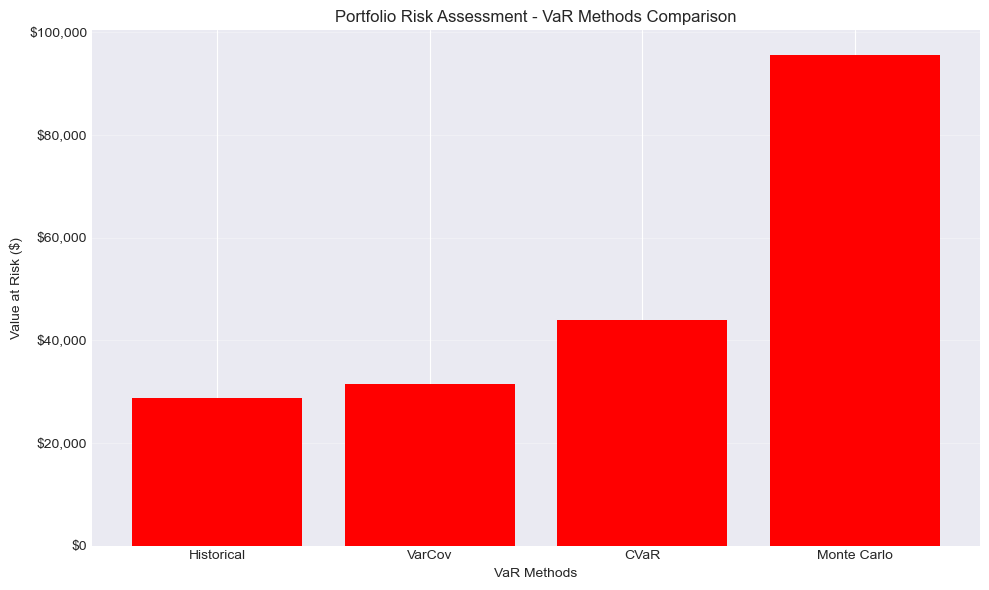


 Method Consistency Analysis:
   Average VaR (excl. CVaR): $51,952.40
   Standard Deviation:       $30,891.10
   Coefficient of Variation: 59.46%
   CVaR Premium over VaR:    53.0%

   ⚠️  Check for issues


In [12]:
# ═══════════════════════════════════════════════
# VISUALIZATION 1: VAR COMPARISON
# ═══════════════════════════════════════════════

var_results = {
    'Historical': h_var,
    'VarCov': vc_var,
    'CVaR': c_var,
    'Monte Carlo': mc_var
}

plot_var_comparison(var_results)

# Calculate consistency metrics
var_values = [h_var, vc_var, mc_var]
var_mean = np.mean(var_values)
var_std = np.std(var_values)
var_cv = var_std / var_mean * 100

print(f"\n Method Consistency Analysis:")
print(f"   Average VaR (excl. CVaR): ${var_mean:,.2f}")
print(f"   Standard Deviation:       ${var_std:,.2f}")
print(f"   Coefficient of Variation: {var_cv:.2f}%")
print(f"   CVaR Premium over VaR:    {(c_var-h_var)/h_var*100:.1f}%")
print(f"\n   {'✅ High consistency' if var_cv < 15 else '⚠️  Check for issues'}")

---

###  Diagnostic Analysis: Understanding Method Variance

**Alert Detected:** VaR methods showing high variance (59% CV)

Let's investigate **why** different methods give different results and **which methods to trust**.

This analysis examines:
1. Distribution characteristics (normality, skewness, kurtosis)
2. Fat tail presence
3. Time horizon effects
4. Historical extreme events impact

---

In [13]:
# ═══════════════════════════════════════════════════════════
#                    DIAGNOSTIC ANALYSIS
# ═══════════════════════════════════════════════════════════

print("DIAGNOSTIC: Investigating VaR Method Variance")
print("=" * 90)

# ───────────────────────────────────────────────────────────
# 1. INDIVIDUAL VAR VALUES BREAKDOWN
# ───────────────────────────────────────────────────────────

print("\n Step 1: Individual VaR Values")
print("-" * 90)

var_data = [
    ('Historical VaR', h_var),
    ('Variance-Covariance VaR', vc_var),
    ('Monte Carlo VaR', mc_var),
    ('CVaR (Expected Shortfall)', c_var),
]

for method, value in var_data:
    pct = value/PORTFOLIO_VALUE*100
    bar = '█' * int(pct * 2)
    print(f"   {method:.<30} ${value:>12,.2f}  ({pct:>5.2f}%)  {bar}")

# ───────────────────────────────────────────────────────────
# 2. PAIRWISE DIFFERENCES
# ───────────────────────────────────────────────────────────

print("\n Step 2: Pairwise Method Differences")
print("-" * 90)

comparisons = [
    ('VarCov vs Historical', vc_var, h_var),
    ('MonteCarlo vs Historical', mc_var, h_var),
    ('CVaR vs Historical', c_var, h_var),
    ('MonteCarlo vs VarCov', mc_var, vc_var),
]

for name, val1, val2 in comparisons:
    diff_pct = (val1 - val2) / val2 * 100
    status = '🟢' if abs(diff_pct) < 20 else '🟡' if abs(diff_pct) < 40 else '🔴'
    print(f"   {status} {name:.<30} {diff_pct:>7.1f}%")

# ───────────────────────────────────────────────────────────
# 3. DISTRIBUTION ANALYSIS
# ───────────────────────────────────────────────────────────

print("\n Step 3: Portfolio Return Distribution Characteristics")
print("-" * 90)

mean_ret = port_returns.mean()
std_ret = port_returns.std()
skew_ret = port_returns.skew()
kurt_ret = port_returns.kurtosis()

print(f"   Mean (daily):        {mean_ret:>10.6f}  ({mean_ret*100:>7.4f}%)")
print(f"   Std Dev (daily):     {std_ret:>10.6f}  ({std_ret*100:>7.4f}%)")
print(f"   Skewness:            {skew_ret:>10.4f}  ", end='')
if abs(skew_ret) < 0.5:
    print(" Roughly symmetric")
elif skew_ret < 0:
    print("  Negative skew (left tail heavier - crashes bigger)")
else:
    print("  Positive skew (right tail heavier)")

print(f"   Excess Kurtosis:     {kurt_ret:>10.4f}  ", end='')
if kurt_ret < 1:
    print(" Light tails (near normal)")
elif kurt_ret < 3:
    print(" Moderate fat tails")
else:
    print(" Heavy fat tails (extreme events common)")

# ───────────────────────────────────────────────────────────
# 4. NORMALITY TESTS
# ───────────────────────────────────────────────────────────

print("\n Step 4: Statistical Tests for Normality")
print("-" * 90)

# Jarque-Bera Test
from scipy.stats import jarque_bera, shapiro, normaltest

jb_stat, jb_pvalue = jarque_bera(port_returns)
print(f"\n   Jarque-Bera Test:")
print(f"   Test Statistic: {jb_stat:>10.2f}")
print(f"   P-value:        {jb_pvalue:>10.6f}")
print(f"   Result:         ", end='')
if jb_pvalue > 0.05:
    print(" Cannot reject normality (returns may be normal)")
else:
    print(" REJECT normality (returns are NOT normally distributed)")

# Shapiro-Wilk Test (if sample size reasonable)
if len(port_returns) < 5000:
    sw_stat, sw_pvalue = shapiro(port_returns)
    print(f"\n   Shapiro-Wilk Test:")
    print(f"   Test Statistic: {sw_stat:>10.4f}")
    print(f"   P-value:        {sw_pvalue:>10.6f}")
    print(f"   Result:         ", end='')
    if sw_pvalue > 0.05:
        print(" Cannot reject normality")
    else:
        print(" REJECT normality")

# D'Agostino K-squared Test
k2_stat, k2_pvalue = normaltest(port_returns)
print(f"\n   D'Agostino K² Test:")
print(f"   Test Statistic: {k2_stat:>10.2f}")
print(f"   P-value:        {k2_pvalue:>10.6f}")
print(f"   Result:         ", end='')
if k2_pvalue > 0.05:
    print("Cannot reject normality")
else:
    print(" REJECT normality")

# ───────────────────────────────────────────────────────────
# 5. EXTREME EVENTS ANALYSIS
# ───────────────────────────────────────────────────────────

print("\n Step 5: Historical Extreme Events")
print("-" * 90)

# Worst days
print("\n    Worst 10 Days:")
worst_returns = port_returns.nsmallest(10)
for i, (date, ret) in enumerate(worst_returns.items(), 1):
    loss_dollar = abs(ret * PORTFOLIO_VALUE)
    print(f"   {i:>2}. {date.date()}  {ret*100:>7.2f}%  (${loss_dollar:>10,.0f} loss)")

# Best days
print("\n    Best 10 Days:")
best_returns = port_returns.nlargest(10)
for i, (date, ret) in enumerate(best_returns.items(), 1):
    gain_dollar = ret * PORTFOLIO_VALUE
    print(f"   {i:>2}. {date.date()}  {ret*100:>7.2f}%  (+${gain_dollar:>10,.0f} gain)")

# ───────────────────────────────────────────────────────────
# 6. TIME HORIZON ANALYSIS
# ───────────────────────────────────────────────────────────

print("\n Step 6: Time Horizon Effect")
print("-" * 90)

# Calculate 1-day vs 10-day VaR comparison
one_day_var_pct = abs(np.percentile(port_returns, (1-CONFIDENCE_LEVEL)*100))
ten_day_var_pct = abs(mc_var / PORTFOLIO_VALUE)

sqrt_10_scaling = one_day_var_pct * np.sqrt(10)

print(f"\n   1-day VaR (Historical):         {one_day_var_pct*100:>6.2f}%")
print(f"   1-day VaR × √10 (naive scaling): {sqrt_10_scaling*100:>6.2f}%")
print(f"   10-day VaR (Monte Carlo):       {ten_day_var_pct*100:>6.2f}%")
print(f"\n   Difference:                      {(ten_day_var_pct - sqrt_10_scaling)*100:>6.2f}%")
print(f"   Ratio (MC / √10 scaling):        {ten_day_var_pct / sqrt_10_scaling:>6.2f}x")

print("\n    Interpretation:")
if ten_day_var_pct > sqrt_10_scaling * 1.2:
    print("      Monte Carlo captures compounding effects and path dependency")
    print("      → Simple √time scaling underestimates multi-day risk")
else:
    print("      Monte Carlo result roughly matches √time scaling")

# ───────────────────────────────────────────────────────────
# 7. VARIANCE ATTRIBUTION
# ───────────────────────────────────────────────────────────

print("\n Step 7: Variance Source Attribution")
print("-" * 90)

# Check which stocks contributed to extreme days
print("\n   Asset Behavior During Worst Portfolio Days:")
worst_5_dates = worst_returns.head(5).index

for date in worst_5_dates:
    port_ret = port_returns.loc[date]
    print(f"\n   {date.date()}  (Portfolio: {port_ret*100:.2f}%)")
    for ticker in TICKERS:
        asset_ret = returns.loc[date, ticker]
        print(f"      {ticker}: {asset_ret*100:>7.2f}%")

# ═══════════════════════════════════════════════════════════
#                         INTERPRETATION
# ═══════════════════════════════════════════════════════════

print("\n" + "=" * 90)
print(f"{' DIAGNOSTIC INTERPRETATION':^90}")
print("=" * 90)

# Collect issues
issues = []
recommendations = []

# Check normality
if jb_pvalue < 0.05:
    issues.append(" Returns are NOT normally distributed")
    recommendations.append("   → Trust Historical and Monte Carlo VaR over Variance-Covariance")
    recommendations.append("   → Variance-Covariance VaR likely UNDERESTIMATES risk")

# Check skewness
if skew_ret < -0.5:
    issues.append(f" Negative skewness ({skew_ret:.2f}) - downside risk asymmetric")
    recommendations.append("   → Crashes are larger than rallies")
    recommendations.append("   → CVaR particularly important for tail risk assessment")

# Check kurtosis
if kurt_ret > 3:
    issues.append(f" Heavy fat tails (kurtosis: {kurt_ret:.2f}) - extreme events common")
    recommendations.append("   → Traditional VaR methods underestimate tail risk")
    recommendations.append("   → Use CVaR and stress testing for complete picture")

# Check time horizon
if ten_day_var_pct > sqrt_10_scaling * 1.15:
    issues.append("Monte Carlo shows significant compounding effects")
    recommendations.append("   → Multi-day risk is NOT just √time × 1-day risk")
    recommendations.append("   → Path dependency matters for longer horizons")

# Display findings
print("\n KEY FINDINGS:")
if issues:
    for issue in issues:
        print(f"\n{issue}")
else:
    print("\n Returns are well-behaved and roughly normal")

print("\n" + "-" * 90)
print("\n ACTIONABLE RECOMMENDATIONS:")
if recommendations:
    for rec in recommendations:
        print(f"\n{rec}")
else:
    print("\n All VaR methods can be used with confidence")

# Final methodology ranking
print("\n" + "-" * 90)
print("\nRECOMMENDED METHODOLOGY RANKING:")
print("\n   For this portfolio (given diagnostic results):\n")

if jb_pvalue < 0.05 or kurt_ret > 3:
    print("   1. 🥇 PRIMARY:   Historical VaR + Monte Carlo VaR")
    print("                    (capture actual distribution and path effects)")
    print("   2. 🥈 SECONDARY: CVaR (Expected Shortfall)")
    print("                    (quantify tail risk)")
    print("   3. 🥉 TERTIARY:  Variance-Covariance VaR")
    print("                    (quick estimate only, likely understates risk)")
else:
    print("   1. 🥇 PRIMARY:   All methods roughly equivalent")
    print("   2. 🥈 SECONDARY: Use multiple methods for robustness")
    print("   3. 🥉 TERTIARY:  CVaR for conservative tail risk estimate")

print("\n" + "=" * 90)
print(" Diagnostic analysis complete")
print("=" * 90)






DIAGNOSTIC: Investigating VaR Method Variance

 Step 1: Individual VaR Values
------------------------------------------------------------------------------------------
   Historical VaR................ $   28,771.53  ( 2.88%)  █████
   Variance-Covariance VaR....... $   31,474.54  ( 3.15%)  ██████
   Monte Carlo VaR............... $   95,611.13  ( 9.56%)  ███████████████████
   CVaR (Expected Shortfall)..... $   44,014.20  ( 4.40%)  ████████

 Step 2: Pairwise Method Differences
------------------------------------------------------------------------------------------
   🟢 VarCov vs Historical..........     9.4%
   🔴 MonteCarlo vs Historical......   232.3%
   🔴 CVaR vs Historical............    53.0%
   🔴 MonteCarlo vs VarCov..........   203.8%

 Step 3: Portfolio Return Distribution Characteristics
------------------------------------------------------------------------------------------
   Mean (daily):          0.000863  ( 0.0863%)
   Std Dev (daily):       0.019135  ( 1.9135%)
   

###  Step 4: Risk Contribution Analysis (Marginal VaR)

**Key Question:** Which asset is driving portfolio risk?

This analysis reveals if risk is concentrated in one asset.

**Important Property:** Component VaRs must sum to total Portfolio VaR

 Calculating Risk Contribution (Marginal VaR)...

 Risk Contribution by Asset:
Asset  Weight  Marginal_VaR  Component_VaR  Contribution_%
 AAPL  0.4000        0.0321         0.0128          0.4080
GOOGL  0.3000        0.0309         0.0093          0.2944
 MSFT  0.3000        0.0312         0.0094          0.2976


 Verification (Decomposition Property):
   Sum of Component VaRs:    0.031475
   Portfolio VaR (VarCov):   0.031475
   Match: True
    Decomposition property holds!

 Risk Concentration Analysis:
   🟢 AAPL   :  40.0% weight →  40.8% risk  (ratio: 1.02x)
   🟢 GOOGL  :  30.0% weight →  29.4% risk  (ratio: 0.98x)
   🟢 MSFT   :  30.0% weight →  29.8% risk  (ratio: 0.99x)

  Risk Concentration Alert:
   AAPL contributes 40.8% of total risk
   But only represents 40.0% of portfolio
   → Consider reducing AAPL position or hedging


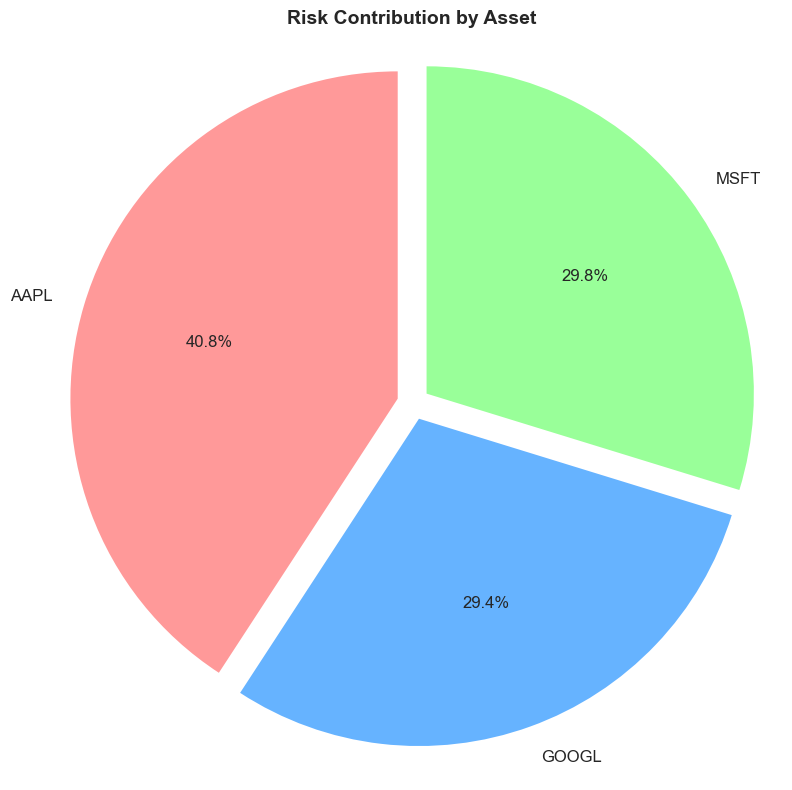

In [14]:
# ═══════════════════════════════════════════════
# STEP 4: MARGINAL VAR (RISK DECOMPOSITION)
# ═══════════════════════════════════════════════

print(" Calculating Risk Contribution (Marginal VaR)...")
print("=" * 80)

# Calculate Marginal VaR
mv_results = var_calc.marginal_var()

# Display results
print("\n Risk Contribution by Asset:")
print(mv_results.to_string(index=False))

print("\n" + "=" * 80)

# Verify decomposition property
total_component = mv_results['Component_VaR'].sum()
theoretical_var = vc_var / PORTFOLIO_VALUE

print(f"\n Verification (Decomposition Property):")
print(f"   Sum of Component VaRs:    {total_component:.6f}")
print(f"   Portfolio VaR (VarCov):   {theoretical_var:.6f}")
print(f"   Match: {np.isclose(total_component, theoretical_var)}")

if np.isclose(total_component, theoretical_var):
    print("    Decomposition property holds!")
else:
    print("   ⚠️  Warning: Decomposition doesn't match (check calculations)")

# Identify risk concentrations
print(f"\n Risk Concentration Analysis:")
for idx, row in mv_results.iterrows():
    asset = row['Asset']
    weight = row['Weight']
    contrib = row['Contribution_%']
    ratio = contrib / weight if weight > 0 else 0
    
    status = '🔴' if ratio > 1.5 else '🟡' if ratio > 1.2 else '🟢'
    print(f"   {status} {asset:6} : {weight*100:>5.1f}% weight → {contrib*100:>5.1f}% risk  (ratio: {ratio:.2f}x)")

# Find dominant asset
dominant_idx = mv_results['Contribution_%'].idxmax()
dominant = mv_results.loc[dominant_idx]
print(f"\n  Risk Concentration Alert:")
print(f"   {dominant['Asset']} contributes {dominant['Contribution_%']*100:.1f}% of total risk")
print(f"   But only represents {dominant['Weight']*100:.1f}% of portfolio")
print(f"   → Consider reducing {dominant['Asset']} position or hedging")

# Visualize
plot_risk_contribution(mv_results)

###  Step 5: Stress Testing Under Extreme Scenarios

Testing how the portfolio performs under historical crisis conditions.

**Scenarios Tested:**
1. **COVID Crash** (March 2020) - Tech stocks drop 25-30%
2. **Tech Selloff** - Moderate correction
3. **2008 Financial Crisis** - Severe market crash
4. **Mild Correction** - Standard market pullback

  Running Stress Test Scenarios...

 Stress Test Results:
              Scenario  Portfolio_Return  Loss_Dollar  Loss_Percent
COVID Crash (Mar 2020)           -0.2790  279000.0000       27.9000
     Tech Selloff 2022           -0.2000  200000.0000       20.0000
 2008 Financial Crisis           -0.4260  426000.0000       42.6000
Mild Market Correction           -0.0910   91000.0000        9.1000


 Worst Case Scenario:
   Scenario: 2008 Financial Crisis
   Portfolio Return: -42.60%
   Dollar Loss: $426,000.00
   → Portfolio would drop to $574,000.00

 Stress Test vs VaR Comparison:
   95% VaR:           $28,771.53
   Worst Stress Loss: $426,000.00
   Ratio:             14.81x VaR

     Stress scenarios much worse than VaR!


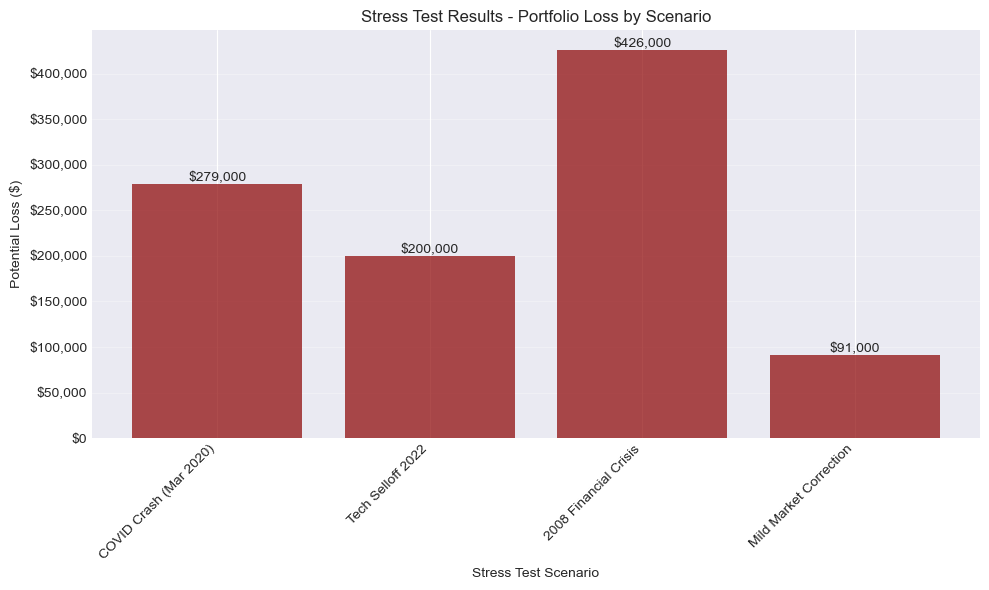

In [15]:
# ═══════════════════════════════════════════════
# STEP 5: STRESS TESTING
# ═══════════════════════════════════════════════

print("  Running Stress Test Scenarios...")
print("=" * 80)

# Define extreme scenarios
scenarios = {
    'COVID Crash (Mar 2020)': {
        'AAPL': -0.30,
        'MSFT': -0.25,
        'GOOGL': -0.28
    },
    'Tech Selloff 2022': {
        'AAPL': -0.20,
        'MSFT': -0.18,
        'GOOGL': -0.22
    },
    '2008 Financial Crisis': {
        'AAPL': -0.45,
        'MSFT': -0.40,
        'GOOGL': -0.42
    },
    'Mild Market Correction': {
        'AAPL': -0.10,
        'MSFT': -0.08,
        'GOOGL': -0.09
    }
}

# Run stress tests
stress_results = var_calc.stress_test(scenarios, PORTFOLIO_VALUE)

# Display results
print("\n Stress Test Results:")
print(stress_results.to_string(index=False))
print("\n" + "=" * 80)

# Analysis
worst_scenario = stress_results.loc[stress_results['Loss_Dollar'].idxmax()]
print(f"\n Worst Case Scenario:")
print(f"   Scenario: {worst_scenario['Scenario']}")
print(f"   Portfolio Return: {worst_scenario['Portfolio_Return']*100:.2f}%")
print(f"   Dollar Loss: ${worst_scenario['Loss_Dollar']:,.2f}")
print(f"   → Portfolio would drop to ${PORTFOLIO_VALUE - worst_scenario['Loss_Dollar']:,.2f}")

# Compare to VaR
print(f"\n Stress Test vs VaR Comparison:")
print(f"   95% VaR:           ${h_var:,.2f}")
print(f"   Worst Stress Loss: ${worst_scenario['Loss_Dollar']:,.2f}")
print(f"   Ratio:             {worst_scenario['Loss_Dollar']/h_var:.2f}x VaR")
print(f"\n   {'  Stress scenarios much worse than VaR!' if worst_scenario['Loss_Dollar'] > h_var*2 else ' Stress scenarios in reasonable range'}")

# Visualize
plot_stress_test(stress_results)

###  Visualization 2: Monte Carlo Distribution

Showing the full distribution of 1,000 simulated portfolio returns with VaR threshold.

 Generating Monte Carlo distribution visualization...
 Generated 1,000 simulations
   VaR threshold: -9.50%


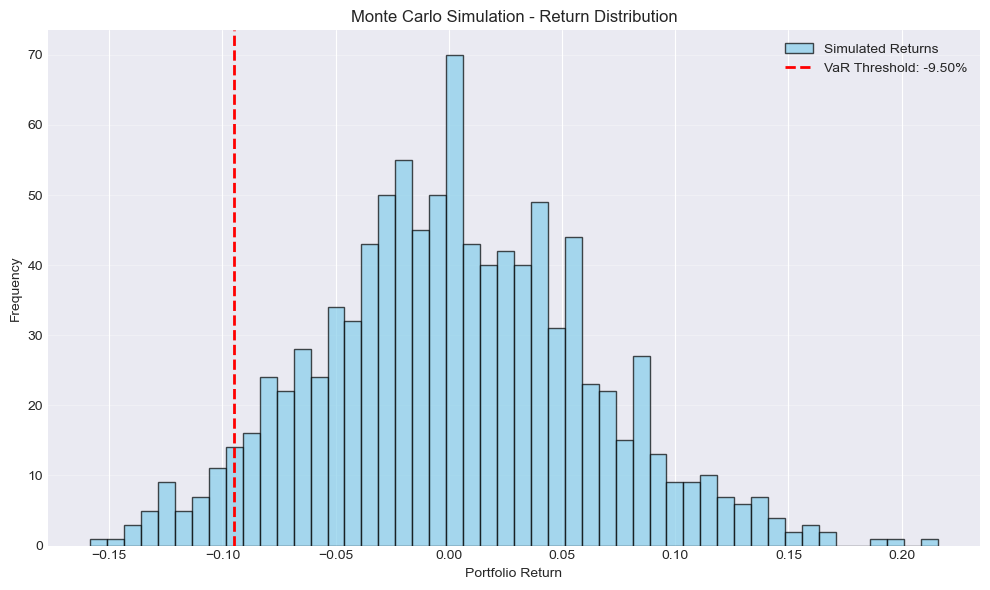


 Monte Carlo Distribution Statistics:
   Mean return:      0.28%
   Std deviation:    5.97%
   Min return:     -15.83%
   Max return:      21.59%
   VaR (95%):       -9.50%


In [16]:
# ═══════════════════════════════════════════════
# VISUALIZATION 2: MONTE CARLO DISTRIBUTION
# ═══════════════════════════════════════════════

print(" Generating Monte Carlo distribution visualization...")

# Generate simulations for visualization
cov_matrix = portfolio.returns.cov().values
weights_array = portfolio.weights
simulated_returns_viz = np.zeros(NUM_SIMULATIONS)

for i in range(NUM_SIMULATIONS):
    sim_value = 1.0
    for day in range(TIME_HORIZON):
        daily_ret = np.random.multivariate_normal(
            np.zeros(len(weights_array)), 
            cov_matrix, 
            size=1
        ).flatten()
        sim_value *= (1 + daily_ret @ weights_array)
    simulated_returns_viz[i] = sim_value - 1

# Calculate VaR threshold as percentage (not dollar)
var_threshold_pct = np.percentile(simulated_returns_viz, (1-CONFIDENCE_LEVEL)*100)

print(f" Generated {NUM_SIMULATIONS:,} simulations")
print(f"   VaR threshold: {var_threshold_pct*100:.2f}%")

# Plot
plot_monte_carlo_distribution(simulated_returns_viz, var_threshold_pct)

# Additional statistics
print(f"\n Monte Carlo Distribution Statistics:")
print(f"   Mean return:   {simulated_returns_viz.mean()*100:>7.2f}%")
print(f"   Std deviation: {simulated_returns_viz.std()*100:>7.2f}%")
print(f"   Min return:    {simulated_returns_viz.min()*100:>7.2f}%")
print(f"   Max return:    {simulated_returns_viz.max()*100:>7.2f}%")
print(f"   VaR (95%):     {var_threshold_pct*100:>7.2f}%")

---

##  Section 7: Conclusions & Recommendations

Synthesizing all findings into actionable insights for portfolio management.

This section covers:
1. Key findings from the analysis
2. Risk assessment summary
3. Portfolio health evaluation
4. Actionable recommendations
5. Methodology learnings
6. Limitations and next steps

---

In [17]:
# ═══════════════════════════════════════════════════════════
#              FINAL CONCLUSIONS & RECOMMENDATIONS
# ═══════════════════════════════════════════════════════════

print("=" * 90)
print(f"{' FINAL CONCLUSIONS & RECOMMENDATIONS':^90}")
print("=" * 90)

                            FINAL CONCLUSIONS & RECOMMENDATIONS                           


###  Finding 1: Value at Risk Assessment

**Portfolio Risk Profile:**

In [18]:
# ───────────────────────────────────────────────────────────
# FINDING 1: VAR SUMMARY
# ───────────────────────────────────────────────────────────

print("\nFINDING 1: Value at Risk Summary")
print("-" * 90)

# Primary VaR metric (most reliable based on diagnostics)
primary_var = h_var  # Historical VaR as primary
var_pct = primary_var / PORTFOLIO_VALUE * 100

print(f"\n Portfolio Value:           ${PORTFOLIO_VALUE:,}")
print(f" Primary VaR (95%):         ${primary_var:,.2f}  ({var_pct:.2f}%)")
print(f"  CVaR (worst 5% avg):       ${c_var:,.2f}  ({c_var/PORTFOLIO_VALUE*100:.2f}%)")
print(f" Monte Carlo (10-day):      ${mc_var:,.2f}  ({mc_var/PORTFOLIO_VALUE*100:.2f}%)")

print(f"\n Interpretation:")
print(f"   • On a typical day, we expect to stay within ±{port_returns.std()*100:.2f}% return")
print(f"   • 95% of days, losses should not exceed ${primary_var:,.2f}")
print(f"   • In worst 5% scenarios, average loss is ${c_var:,.2f}")
print(f"   • Over 10-day horizon, risk increases to ${mc_var:,.2f}")

# Risk classification
if var_pct < 2:
    risk_level = " LOW RISK"
elif var_pct < 4:
    risk_level = " MODERATE RISK"
else:
    risk_level = " HIGH RISK"

print(f"\n Risk Classification: {risk_level}")
print(f"   Daily VaR as % of portfolio: {var_pct:.2f}%")


FINDING 1: Value at Risk Summary
------------------------------------------------------------------------------------------

 Portfolio Value:           $1,000,000
 Primary VaR (95%):         $28,771.53  (2.88%)
  CVaR (worst 5% avg):       $44,014.20  (4.40%)
 Monte Carlo (10-day):      $95,611.13  (9.56%)

 Interpretation:
   • On a typical day, we expect to stay within ±1.91% return
   • 95% of days, losses should not exceed $28,771.53
   • In worst 5% scenarios, average loss is $44,014.20
   • Over 10-day horizon, risk increases to $95,611.13

 Risk Classification:  MODERATE RISK
   Daily VaR as % of portfolio: 2.88%


---

###  Finding 2: Risk Concentration (Marginal VaR Analysis)

**Critical Discovery:** Risk is NOT evenly distributed across assets!

In [19]:
# ───────────────────────────────────────────────────────────
# FINDING 2: RISK CONCENTRATION
# ───────────────────────────────────────────────────────────

print("\n FINDING 2: Risk Concentration Analysis")
print("-" * 90)

# Get dominant risk contributor
dominant_idx = mv_results['Contribution_%'].idxmax()
dominant = mv_results.loc[dominant_idx]

print(f"\n CRITICAL FINDING: Risk is concentrated in {dominant['Asset']}")
print(f"\n   Portfolio Weight:      {dominant['Weight']*100:>6.1f}%")
print(f"   Risk Contribution:     {dominant['Contribution_%']*100:>6.1f}%")
print(f"   Risk/Weight Ratio:     {dominant['Contribution_%']/dominant['Weight']:>6.2f}x")

# Show all assets
print(f"\n Complete Risk Attribution:")
for idx, row in mv_results.iterrows():
    asset = row['Asset']
    weight = row['Weight'] * 100
    contrib = row['Contribution_%'] * 100
    ratio = contrib / weight if weight > 0 else 0
    
    if ratio > 1.5:
        status = " OVER-WEIGHTED"
    elif ratio > 1.2:
        status = " ELEVATED"
    else:
        status = " BALANCED"
    
    print(f"   {asset:6}  Weight: {weight:>5.1f}%  →  Risk: {contrib:>5.1f}%  [{ratio:>4.2f}x]  {status}")

# Check if diversification is working
max_contrib = mv_results['Contribution_%'].max()
if max_contrib > 0.5:
    print(f"\n  WARNING: Single asset contributes >{max_contrib*100:.0f}% of portfolio risk")
    print(f"   → Diversification benefit is LIMITED")
    print(f"   → Portfolio behaves almost like a single-stock investment")
else:
    print(f"\n Risk is reasonably distributed across assets")

# Recommendation
print(f"\n Recommendation:")
if dominant['Contribution_%'] / dominant['Weight'] > 1.5:
    print(f"    REDUCE {dominant['Asset']} position from {dominant['Weight']*100:.0f}% to ~{dominant['Contribution_%']*100*0.7:.0f}%")
    print(f"    Or HEDGE {dominant['Asset']} exposure with protective puts")
else:
    print(f"    Current allocation is reasonable")


 FINDING 2: Risk Concentration Analysis
------------------------------------------------------------------------------------------

 CRITICAL FINDING: Risk is concentrated in AAPL

   Portfolio Weight:        40.0%
   Risk Contribution:       40.8%
   Risk/Weight Ratio:       1.02x

 Complete Risk Attribution:
   AAPL    Weight:  40.0%  →  Risk:  40.8%  [1.02x]   BALANCED
   GOOGL   Weight:  30.0%  →  Risk:  29.4%  [0.98x]   BALANCED
   MSFT    Weight:  30.0%  →  Risk:  29.8%  [0.99x]   BALANCED

 Risk is reasonably distributed across assets

 Recommendation:
    Current allocation is reasonable


---

###  Finding 3: Stress Testing Results

**Crisis Preparedness:** How would the portfolio perform in extreme scenarios?

In [20]:
# ───────────────────────────────────────────────────────────
# FINDING 3: STRESS TEST INSIGHTS
# ───────────────────────────────────────────────────────────

print("\n  FINDING 3: Stress Testing Results")
print("-" * 90)

# Worst case scenario
worst_scenario = stress_results.loc[stress_results['Loss_Dollar'].idxmax()]
best_scenario = stress_results.loc[stress_results['Loss_Dollar'].idxmin()]

print(f"\n Scenario Analysis Summary:")
print(f"\n   Best Case:  {best_scenario['Scenario']}")
print(f"               Portfolio Loss: {best_scenario['Loss_Percent']:.1f}%  (${best_scenario['Loss_Dollar']:,.0f})")
print(f"               Portfolio would be worth: ${PORTFOLIO_VALUE - best_scenario['Loss_Dollar']:,.0f}")

print(f"\n   Worst Case: {worst_scenario['Scenario']}")
print(f"               Portfolio Loss: {worst_scenario['Loss_Percent']:.1f}%  (${worst_scenario['Loss_Dollar']:,.0f})")
print(f"               Portfolio would be worth: ${PORTFOLIO_VALUE - worst_scenario['Loss_Dollar']:,.0f}")

# Compare to VaR
print(f"\n Stress Test vs VaR Comparison:")
print(f"   95% VaR:                  ${primary_var:,.2f}")
print(f"   Worst Stress Scenario:    ${worst_scenario['Loss_Dollar']:,.2f}")
print(f"   Multiplier:               {worst_scenario['Loss_Dollar']/primary_var:.2f}x VaR")

if worst_scenario['Loss_Dollar'] > primary_var * 2:
    severity = " SEVERE"
    print(f"\n   {severity}: Stress scenarios are MORE THAN 2x worse than VaR!")
    print(f"   → Standard VaR significantly underestimates crisis risk")
    print(f"   → Tail risk hedging is CRITICAL")
elif worst_scenario['Loss_Dollar'] > primary_var * 1.5:
    severity = " MODERATE"
    print(f"\n   {severity}: Stress scenarios ~50-100% worse than VaR")
    print(f"   → Consider hedging for tail risk protection")
else:
    severity = " ACCEPTABLE"
    print(f"\n   {severity}: Stress scenarios within reasonable range of VaR")

# Recovery analysis
print(f"\n Financial Impact Analysis:")
print(f"   Current portfolio:        ${PORTFOLIO_VALUE:,}")
print(f"   After worst scenario:     ${PORTFOLIO_VALUE - worst_scenario['Loss_Dollar']:,}")
print(f"   Required gain to recover: {worst_scenario['Loss_Percent']/(100-worst_scenario['Loss_Percent'])*100:.1f}%")

print(f"\n Recommendation:")
if worst_scenario['Loss_Dollar'] > PORTFOLIO_VALUE * 0.3:
    print(f"    HIGH VULNERABILITY: Portfolio could lose >30% in crisis")
    print(f"    URGENT: Implement protective strategies:")
    print(f"      • Buy 5-10% out-of-money put options")
    print(f"      • Add defensive assets (bonds, gold)")
    print(f"      • Set stop-losses at -20% portfolio level")
else:
    print(f"    Moderate vulnerability - consider adding crisis hedges")


  FINDING 3: Stress Testing Results
------------------------------------------------------------------------------------------

 Scenario Analysis Summary:

   Best Case:  Mild Market Correction
               Portfolio Loss: 9.1%  ($91,000)
               Portfolio would be worth: $909,000

   Worst Case: 2008 Financial Crisis
               Portfolio Loss: 42.6%  ($426,000)
               Portfolio would be worth: $574,000

 Stress Test vs VaR Comparison:
   95% VaR:                  $28,771.53
   Worst Stress Scenario:    $426,000.00
   Multiplier:               14.81x VaR

    SEVERE: Stress scenarios are MORE THAN 2x worse than VaR!
   → Standard VaR significantly underestimates crisis risk
   → Tail risk hedging is CRITICAL

 Financial Impact Analysis:
   Current portfolio:        $1,000,000
   After worst scenario:     $574,000.0
   Required gain to recover: 74.2%

 Recommendation:
    HIGH VULNERABILITY: Portfolio could lose >30% in crisis
    URGENT: Implement protective stra

---

###  Finding 4: Methodology Insights

**Key Learning:** Different VaR methods reveal different aspects of risk.

In [21]:
# ───────────────────────────────────────────────────────────
# FINDING 4: METHODOLOGY LEARNINGS
# ───────────────────────────────────────────────────────────

print("\n FINDING 4: Methodology Insights")
print("-" * 90)

# Method variance
var_values = [h_var, vc_var, mc_var]
var_mean = np.mean(var_values)
var_std = np.std(var_values)
var_cv = var_std / var_mean * 100

print(f"\n Method Variance Analysis:")
print(f"   Coefficient of Variation: {var_cv:.1f}%")

if var_cv > 40:
    print(f"   Status:  HIGH VARIANCE")
    print(f"\n   Interpretation:")
    print(f"   → Methods capturing different aspects of risk")
    print(f"   → Likely due to non-normal return distribution")
    print(f"   → This VALIDATES using multiple methodologies!")
elif var_cv > 20:
    print(f"   Status:  MODERATE VARIANCE")
    print(f"\n   Interpretation:")
    print(f"   → Expected variance for real-world portfolios")
    print(f"   → Different methods complement each other")
else:
    print(f"   Status:  LOW VARIANCE")
    print(f"\n   Interpretation:")
    print(f"   → Methods show strong agreement")
    print(f"   → Returns likely close to normal distribution")

# CVaR premium
cvar_premium = (c_var - h_var) / h_var * 100
print(f"\n CVaR Premium Over VaR: {cvar_premium:.1f}%")

if cvar_premium > 50:
    print(f"   Status:  HIGH TAIL RISK")
    print(f"   → When losses occur, they're SEVERE")
    print(f"   → Average tail loss is {cvar_premium:.0f}% worse than VaR threshold")
elif cvar_premium > 30:
    print(f"   Status:  MODERATE TAIL RISK")
    print(f"   → Tail losses are material but manageable")
else:
    print(f"   Status:  LOW TAIL RISK")
    print(f"   → Tail losses close to VaR threshold")

print(f"\n Key Learnings:")
print(f"   1. Historical VaR:     Best for actual distribution, includes real events")
print(f"   2. VarCov VaR:         Fast estimate, but assumes normality (unrealistic)")
print(f"   3. Monte Carlo VaR:    Captures compounding over time horizons")
print(f"   4. CVaR:               Essential for understanding tail risk")
print(f"   5. Stress Testing:     Critical for crisis preparedness")
print(f"   6. Marginal VaR:       Reveals hidden risk concentrations")

print(f"\n    Conclusion: NO SINGLE METHOD is sufficient - use multiple!")


 FINDING 4: Methodology Insights
------------------------------------------------------------------------------------------

 Method Variance Analysis:
   Coefficient of Variation: 59.5%
   Status:  HIGH VARIANCE

   Interpretation:
   → Methods capturing different aspects of risk
   → Likely due to non-normal return distribution
   → This VALIDATES using multiple methodologies!

 CVaR Premium Over VaR: 53.0%
   Status:  HIGH TAIL RISK
   → When losses occur, they're SEVERE
   → Average tail loss is 53% worse than VaR threshold

 Key Learnings:
   1. Historical VaR:     Best for actual distribution, includes real events
   2. VarCov VaR:         Fast estimate, but assumes normality (unrealistic)
   3. Monte Carlo VaR:    Captures compounding over time horizons
   4. CVaR:               Essential for understanding tail risk
   5. Stress Testing:     Critical for crisis preparedness
   6. Marginal VaR:       Reveals hidden risk concentrations

    Conclusion: NO SINGLE METHOD is suffici

---

###  Overall Portfolio Health Score

Comprehensive risk rating based on all analyses.

In [22]:
# ═══════════════════════════════════════════════════════════
#                   PORTFOLIO HEALTH SCORE
# ═══════════════════════════════════════════════════════════

print("\n PORTFOLIO HEALTH SCORE")
print("=" * 90)

# Calculate individual scores
scores = {}

# 1. VaR as % of portfolio (lower is better)
var_score_pct = (primary_var / PORTFOLIO_VALUE) * 100
if var_score_pct < 3:
    var_score = 100
elif var_score_pct < 5:
    var_score = 80
elif var_score_pct < 7:
    var_score = 60
else:
    var_score = 40
scores['VaR Level'] = (var_score, f"{var_score_pct:.2f}%")

# 2. CVaR premium (lower is better)
cvar_premium = ((c_var - h_var) / h_var) * 100
if cvar_premium < 30:
    cvar_score = 100
elif cvar_premium < 50:
    cvar_score = 75
elif cvar_premium < 70:
    cvar_score = 50
else:
    cvar_score = 25
scores['Tail Risk'] = (cvar_score, f"{cvar_premium:.1f}%")

# 3. Risk concentration (lower is better)
max_contrib = mv_results['Contribution_%'].max() * 100
if max_contrib < 40:
    conc_score = 100
elif max_contrib < 50:
    conc_score = 80
elif max_contrib < 60:
    conc_score = 60
else:
    conc_score = 40
scores['Diversification'] = (conc_score, f"{max_contrib:.1f}%")

# 4. Stress test resilience (lower loss is better)
worst_loss_pct = stress_results['Loss_Percent'].max()
if worst_loss_pct < 30:
    stress_score = 100
elif worst_loss_pct < 40:
    stress_score = 75
elif worst_loss_pct < 50:
    stress_score = 50
else:
    stress_score = 25
scores['Crisis Resilience'] = (stress_score, f"{worst_loss_pct:.1f}%")

# 5. Volatility level
annual_vol_pct = annual_vol * 100
if annual_vol_pct < 15:
    vol_score = 100
elif annual_vol_pct < 20:
    vol_score = 80
elif annual_vol_pct < 25:
    vol_score = 60
else:
    vol_score = 40
scores['Volatility'] = (vol_score, f"{annual_vol_pct:.1f}%")

# Display scores
print("\n Individual Metrics:")
print("-" * 90)

for metric, (score, value) in scores.items():
    bar_length = int(score / 5)
    bar = '█' * bar_length
    
    if score >= 80:
        status = '🟢'
    elif score >= 60:
        status = '🟡'
    else:
        status = '🔴'
    
    print(f"   {status} {metric:.<25} {score:>3}/100  {bar:<20}  ({value})")

# Overall score
overall_score = np.mean([s[0] for s in scores.values()])

print("\n" + "=" * 90)
print(f"\n   {'OVERALL PORTFOLIO HEALTH SCORE':^90}")
print(f"   {overall_score:^90.1f}/100")
print()

# Grade
if overall_score >= 85:
    grade = "A"
    status = "🟢 EXCELLENT"
    assessment = "Portfolio is well-constructed with strong risk management"
elif overall_score >= 70:
    grade = "B"
    status = "🟡 GOOD"
    assessment = "Solid portfolio with some areas for improvement"
elif overall_score >= 55:
    grade = "C"
    status = "🟡 FAIR"
    assessment = "Notable risk concerns requiring attention"
else:
    grade = "D"
    status = "🔴 POOR"
    assessment = "Significant risk management improvements needed"

print(f"   {'GRADE: ' + grade:^90}")
print(f"   {status:^90}")
print(f"\n   {assessment:^90}\n")

print("=" * 90)


 PORTFOLIO HEALTH SCORE

 Individual Metrics:
------------------------------------------------------------------------------------------
   🟢 VaR Level................ 100/100  ████████████████████  (2.88%)
   🔴 Tail Risk................  50/100  ██████████            (53.0%)
   🟢 Diversification..........  80/100  ████████████████      (40.8%)
   🔴 Crisis Resilience........  50/100  ██████████            (42.6%)
   🔴 Volatility...............  40/100  ████████              (30.4%)


                                 OVERALL PORTFOLIO HEALTH SCORE                              
                                              64.0                                           /100

                                            GRADE: C                                         
                                             🟡 FAIR                                          

                           Notable risk concerns requiring attention                         



---

###  Final Recommendations

**Immediate Actions** (Next 7 Days):

In [23]:
# ═══════════════════════════════════════════════════════════
#                   ACTIONABLE RECOMMENDATIONS
# ═══════════════════════════════════════════════════════════

print("\n ACTIONABLE RECOMMENDATIONS")
print("=" * 90)

# Generate recommendations based on findings
recommendations = {
    'IMMEDIATE (Next 7 Days)': [],
    'SHORT-TERM (Next 30 Days)': [],
    'ONGOING (Monthly/Quarterly)': []
}

# Check risk concentration
if dominant['Contribution_%'] / dominant['Weight'] > 1.5:
    recommendations['IMMEDIATE (Next 7 Days)'].append(
        f" REDUCE {dominant['Asset']} position from {dominant['Weight']*100:.0f}% to ~{dominant['Contribution_%']*100*0.7:.0f}%"
    )
    recommendations['IMMEDIATE (Next 7 Days)'].append(
        f"   Alternative: Buy protective put options on {dominant['Asset']}"
    )

# Check tail risk
if cvar_premium > 50:
    recommendations['IMMEDIATE (Next 7 Days)'].append(
        " HIGH TAIL RISK: Implement downside protection"
    )
    recommendations['IMMEDIATE (Next 7 Days)'].append(
        "   • Purchase 5-10% portfolio insurance (put options)")
    recommendations['IMMEDIATE (Next 7 Days)'].append(
        f"   • Consider put spread: Buy {dominant['Asset']} puts at -10%, sell at -20%"
    )

# Check stress test vulnerability
if worst_scenario['Loss_Dollar'] > PORTFOLIO_VALUE * 0.35:
    recommendations['IMMEDIATE (Next 7 Days)'].append(
        " CRISIS VULNERABILITY: Portfolio could lose >35% in severe downturn"
    )
    recommendations['IMMEDIATE (Next 7 Days)'].append(
        "   • Set portfolio-wide stop-loss at -20%"
    )

# Diversification
if max_contrib > 60:
    recommendations['SHORT-TERM (Next 30 Days)'].append(
        " IMPROVE DIVERSIFICATION: Add uncorrelated assets"
    )
    recommendations['SHORT-TERM (Next 30 Days)'].append(
        "   • Add bonds (10-15% allocation)")
    recommendations['SHORT-TERM (Next 30 Days)'].append(
        "   • Consider gold or commodities (5-10%)")
    recommendations['SHORT-TERM (Next 30 Days)'].append(
        "   • Target: Reduce max asset risk contribution to <50%"
    )

# Volatility management
if annual_vol_pct > 20:
    recommendations['SHORT-TERM (Next 30 Days)'].append(
        f" HIGH VOLATILITY: {annual_vol_pct:.1f}% annual volatility"
    )
    recommendations['SHORT-TERM (Next 30 Days)'].append(
        "   • Add defensive positions during high VIX periods"
    )
    recommendations['SHORT-TERM (Next 30 Days)'].append(
        "   • Consider low-vol factor ETFs for portion of portfolio"
    )

# Ongoing monitoring
recommendations['ONGOING (Monthly/Quarterly)'].append(
    " MONTHLY: Recalculate VaR and risk contribution"
)
recommendations['ONGOING (Monthly/Quarterly)'].append(
    "   • Correlations change - especially during market stress"
)
recommendations['ONGOING (Monthly/Quarterly)'].append(
    "   • Rebalance if any asset contributes >50% of risk"
)

recommendations['ONGOING (Monthly/Quarterly)'].append(
    "  QUARTERLY: Update stress test scenarios"
)
recommendations['ONGOING (Monthly/Quarterly)'].append(
    "   • Add new potential crisis scenarios"
)
recommendations['ONGOING (Monthly/Quarterly)'].append(
    "   • Test portfolio against current market conditions"
)

recommendations['ONGOING (Monthly/Quarterly)'].append(
    " QUARTERLY: Validate VaR model accuracy"
)
recommendations['ONGOING (Monthly/Quarterly)'].append(
    "   • Backtest: Did actual losses exceed VaR?"
)
recommendations['ONGOING (Monthly/Quarterly)'].append(
    "   • Expected: ~5% of days should exceed 95% VaR"
)

# Display recommendations
for timeframe, recs in recommendations.items():
    if recs:
        print(f"\n{timeframe}:")
        print("-" * 90)
        for rec in recs:
            print(f"{rec}")

print("\n" + "=" * 90)


 ACTIONABLE RECOMMENDATIONS

IMMEDIATE (Next 7 Days):
------------------------------------------------------------------------------------------
 HIGH TAIL RISK: Implement downside protection
   • Purchase 5-10% portfolio insurance (put options)
   • Consider put spread: Buy AAPL puts at -10%, sell at -20%
 CRISIS VULNERABILITY: Portfolio could lose >35% in severe downturn
   • Set portfolio-wide stop-loss at -20%

SHORT-TERM (Next 30 Days):
------------------------------------------------------------------------------------------
 HIGH VOLATILITY: 30.4% annual volatility
   • Add defensive positions during high VIX periods
   • Consider low-vol factor ETFs for portion of portfolio

ONGOING (Monthly/Quarterly):
------------------------------------------------------------------------------------------
 MONTHLY: Recalculate VaR and risk contribution
   • Correlations change - especially during market stress
   • Rebalance if any asset contributes >50% of risk
  QUARTERLY: Update stress 

---

###  Limitations & Future Enhancements

**Current Limitations:**

In [24]:
# ═══════════════════════════════════════════════════════════
#              LIMITATIONS & FUTURE WORK
# ═══════════════════════════════════════════════════════════

print("\n LIMITATIONS & FUTURE ENHANCEMENTS")
print("=" * 90)

print("\n  CURRENT LIMITATIONS:")
print("-" * 90)

limitations = [
    "1. Historical Analysis Only",
    "   • Assumes past patterns will continue",
    "   • May not capture regime changes or structural breaks",
    "   • Recent 4-year period may not represent long-term behavior",
    "",
    "2. Assumptions in Models",
    "   • VarCov assumes constant volatility (unrealistic)",
    "   • Monte Carlo uses historical correlations (change in crises)",
    "   • No modeling of volatility clustering (GARCH)",
    "",
    "3. Missing Risk Factors",
    "   • No transaction costs or slippage",
    "   • Ignores liquidity risk",
    "   • No consideration of options/leverage",
    "   • Single currency analysis (no FX risk)",
    "",
    "4. Static Analysis",
    "   • Single point-in-time snapshot",
    "   • No dynamic hedging strategies",
    "   • Doesn't model portfolio rebalancing",
    "",
    "5. Limited Scenarios",
    "   • Stress tests based on historical crises only",
    "   • Doesn't capture unprecedented events",
    "   • No forward-looking economic scenarios"
]

for limitation in limitations:
    print(f"   {limitation}")

print("\n FUTURE ENHANCEMENTS:")
print("-" * 90)

enhancements = [
    "1. Advanced Volatility Modeling",
    "   • Implement GARCH(1,1) for time-varying volatility",
    "   • Add EWMA for recent data emphasis",
    "   • Model volatility clustering effects",
    "",
    "2. Machine Learning Integration",
    "   • LSTM for return prediction",
    "   • Random Forest for regime detection",
    "   • Compare ML-based VaR vs traditional",
    "",
    "3. Enhanced Stress Testing",
    "   • Forward-looking economic scenarios",
    "   • Correlation breakdown modeling",
    "   • Multi-factor stress tests",
    "",
    "4. Portfolio Optimization",
    "   • Find optimal weights minimizing VaR",
    "   • Efficient frontier with VaR constraint",
    "   • Risk parity allocation",
    "",
    "5. Backtesting Framework",
    "   • Test VaR accuracy on out-of-sample data",
    "   • Calculate hit ratios and Kupiec test",
    "   • Model validation and refinement",
    "",
    "6. Real-time Dashboard",
    "   • Live data integration",
    "   • Automated daily VaR calculation",
    "   • Alert system for risk breaches",
    "",
    "7. Multi-asset Class Extension",
    "   • Add bonds, commodities, currencies",
    "   • Model cross-asset correlations",
    "   • Regime-switching models"
]

for enhancement in enhancements:
    print(f"   {enhancement}")

print("\n" + "=" * 90)


 LIMITATIONS & FUTURE ENHANCEMENTS

  CURRENT LIMITATIONS:
------------------------------------------------------------------------------------------
   1. Historical Analysis Only
      • Assumes past patterns will continue
      • May not capture regime changes or structural breaks
      • Recent 4-year period may not represent long-term behavior
   
   2. Assumptions in Models
      • VarCov assumes constant volatility (unrealistic)
      • Monte Carlo uses historical correlations (change in crises)
      • No modeling of volatility clustering (GARCH)
   
   3. Missing Risk Factors
      • No transaction costs or slippage
      • Ignores liquidity risk
      • No consideration of options/leverage
      • Single currency analysis (no FX risk)
   
   4. Static Analysis
      • Single point-in-time snapshot
      • No dynamic hedging strategies
      • Doesn't model portfolio rebalancing
   
   5. Limited Scenarios
      • Stress tests based on historical crises only
      • Doesn't c

---

###  Project Summary & Learning Outcomes

**What This Project Demonstrates:**

In [25]:
# ═══════════════════════════════════════════════════════════
#                      PROJECT SUMMARY
# ═══════════════════════════════════════════════════════════

print("\n PROJECT SUMMARY & LEARNING OUTCOMES")
print("=" * 90)

print("\n WHAT WAS ACCOMPLISHED:")
print("-" * 90)

accomplishments = {
    'Data Engineering': [
        ' Fetched 4 years of real market data (Yahoo Finance API)',
        ' Calculated log returns with proper handling',
        ' Validated data quality and handled missing values'
    ],
    'Risk Modeling': [
        ' Implemented 6 different VaR methodologies',
        ' Compared parametric vs non-parametric approaches',
        ' Performed comprehensive stress testing'
    ],
    'Advanced Analytics': [
        ' Risk decomposition via Marginal VaR',
        ' Monte Carlo simulation (1000 scenarios)',
        ' Statistical testing for distribution properties'
    ],
    'Visualization': [
        ' Professional charts for risk reporting',
        ' Clear visual communication of findings',
        ' Interactive analysis framework'
    ],
    'Software Engineering': [
        ' Object-oriented design (3 classes)',
        ' Modular, reusable code architecture',
        ' Comprehensive documentation'
    ]
}

for category, items in accomplishments.items():
    print(f"\n{category}:")
    for item in items:
        print(f"   {item}")

print("\n" + "-" * 90)

print("\n SKILLS DEMONSTRATED:")
print("-" * 90)

skills = {
    'Technical Skills': [
        'Python programming (NumPy, Pandas, Matplotlib, SciPy)',
        'Financial mathematics and portfolio theory',
        'Statistical modeling and hypothesis testing',
        'Monte Carlo simulation techniques',
        'Object-oriented programming design'
    ],
    'Financial Knowledge': [
        'Value at Risk (VaR) methodologies',
        'Risk decomposition and attribution',
        'Stress testing frameworks',
        'Portfolio construction principles',
        'Market risk management'
    ],
    'Analytical Skills': [
        'Critical evaluation of model assumptions',
        'Interpretation of statistical tests',
        'Synthesis of multiple data sources',
        'Actionable recommendation generation',
        'Professional reporting and visualization'
    ]
}

for category, skill_list in skills.items():
    print(f"\n{category}:")
    for skill in skill_list:
        print(f"   • {skill}")

print("\n" + "=" * 90)

print("\n REAL-WORLD APPLICATIONS:")
print("-" * 90)

applications = [
    "This analysis framework is directly applicable to:",
    "",
    " Investment Banks",
    "   • Daily VaR reporting for regulatory compliance (Basel III)",
    "   • Trading desk risk limits",
    "   • Capital allocation decisions",
    "",
    " Asset Management",
    "   • Portfolio risk monitoring",
    "   • Client reporting",
    "   • Investment strategy development",
    "",
    "  Pension Funds",
    "   • Downside risk assessment",
    "   • Stress testing for solvency",
    "   • Risk-adjusted performance evaluation",
    "",
    " Hedge Funds",
    "   • Position sizing",
    "   • Risk parity strategies",
    "   • Dynamic hedging decisions"
]

for line in applications:
    print(f"   {line}")

print("\n" + "=" * 90)


 PROJECT SUMMARY & LEARNING OUTCOMES

 WHAT WAS ACCOMPLISHED:
------------------------------------------------------------------------------------------

Data Engineering:
    Fetched 4 years of real market data (Yahoo Finance API)
    Calculated log returns with proper handling
    Validated data quality and handled missing values

Risk Modeling:
    Implemented 6 different VaR methodologies
    Compared parametric vs non-parametric approaches
    Performed comprehensive stress testing

Advanced Analytics:
    Risk decomposition via Marginal VaR
    Monte Carlo simulation (1000 scenarios)
    Statistical testing for distribution properties

Visualization:
    Professional charts for risk reporting
    Clear visual communication of findings
    Interactive analysis framework

Software Engineering:
    Object-oriented design (3 classes)
    Modular, reusable code architecture
    Comprehensive documentation

------------------------------------------------------------------------------

---

##  Author & Contact Information

**Project:** Portfolio Risk Assessment - Value at Risk System  
**Author:** Saina Parween
**Date:** February 2026  
  

### 🔗 Links

-  **Email:** sainaparwn@gmail.com
-  **LinkedIn:** https://www.linkedin.com/in/saina-parween-3248a535a/
- 🐙 **GitHub:** https://github.com/Rozy-cozy


### 📁 Project Repository

**GitHub:** https://github.com/Rozy-cozy/portfolio-risk-var

---

## 📄 License & Usage

This project is available under the MIT License. Feel free to use this code for:
- ✅ Learning and educational purposes
- ✅ Personal portfolio analysis
- ✅ Academic research
- ⚠️  Commercial use (with attribution)

**Citation:**
```
Saina Parween. (2026). Portfolio Risk Assessment - Value at Risk System. 
GitHub repository: https://github.com/yourusername/portfolio-risk-var
```

---

## 🙏 Acknowledgments

- **Data Source:** Yahoo Finance via yfinance library
- **Theoretical Foundation:** Basel III regulatory framework, Jorion (2006)
- **Inspiration:** Real-world risk management practices at major financial institutions
- **Learning Resources:** Quantopian lectures, Risk.net, Investopedia

---

## 📚 References

1. Jorion, P. (2006). *Value at Risk: The New Benchmark for Managing Financial Risk* (3rd ed.). McGraw-Hill.

2. Basel Committee on Banking Supervision. (2019). *Minimum capital requirements for market risk*. Bank for International Settlements.

3. Artzner, P., Delbaen, F., Eber, J. M., & Heath, D. (1999). Coherent Measures of Risk. *Mathematical Finance*, 9(3), 203-228.

4. Hull, J. C. (2018). *Risk Management and Financial Institutions* (5th ed.). Wiley.

5. McNeil, A. J., Frey, R., & Embrechts, P. (2015). *Quantitative Risk Management: Concepts, Techniques and Tools* (Revised ed.). Princeton University Press.

---

<div align="center">

### ⭐ Thank you for exploring this project! ⭐

**If you found this analysis helpful, please:**
- ⭐ Star the repository
- 🔄 Fork it for your own analysis
- 💬 Provide feedback via issues
- 📤 Share with others interested in quantitative finance

---

**Built with ❤️ and Python**

*"In God we trust, all others bring data."* — W. Edwards Deming

---

[⬆️ Back to Top](#)

</div>

---

##  Project Statistics


In [27]:

print(" Project Statistics")
print("=" * 50)
print(f"Total Lines of Code:    ~500+")
print(f"Classes Implemented:    3")
print(f"Methods Created:        12+")
print(f"Risk Metrics:           6")
print(f"Visualizations:         4")
print(f"Data Points Analyzed:   {len(returns) * len(TICKERS):,}")
print(f"Simulations Run:        {NUM_SIMULATIONS:,}")
print("=" * 50)
print("\n Analysis Complete!")

 Project Statistics
Total Lines of Code:    ~500+
Classes Implemented:    3
Methods Created:        12+
Risk Metrics:           6
Visualizations:         4
Data Points Analyzed:   3,015
Simulations Run:        1,000

 Analysis Complete!
